In [2]:

import subprocess, sys

_pkgs = [
    "sentence-transformers==3.3.1",
    "faiss-cpu",
    "rank-bm25",
    "transformers>=4.40.0",
    "datasets",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "tqdm",
    "pandas",
    "numpy",
    "accelerate",
    "scipy",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _pkgs)
print(" All packages installed")


 All packages installed


In [3]:

import os, sys
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = "/content/drive/MyDrive"
else:
    DRIVE_ROOT = os.environ.get("DRIVE_ROOT", "/content/drive/MyDrive")
    print("Colab not detected. Using DRIVE_ROOT =", DRIVE_ROOT)

PAN_DRIVE_DIR_CANDIDATES = [
    f"{DRIVE_ROOT}/PAN2025",
    f"{DRIVE_ROOT}",
]

PAN_DRIVE_DIR = PAN_DRIVE_DIR_CANDIDATES[0]
for cand in PAN_DRIVE_DIR_CANDIDATES:
    if (Path(f"{cand}/pan25-generated-plagiarism-detection-train.zip").exists() or
            Path(f"{cand}/pan25-generated-plagiarism-detection-validation.zip").exists()):
        PAN_DRIVE_DIR = cand
        break

PAN_TRAIN_ZIP       = f"{PAN_DRIVE_DIR}/pan25-generated-plagiarism-detection-train.zip"
PAN_VAL_ZIP         = f"{PAN_DRIVE_DIR}/pan25-generated-plagiarism-detection-validation.zip"
PAN_SPOT_LOCAL_ZIP  = "/content/pan25-generated-plagiarism-detection-spot-check.zip"
QQP_LOCAL_OUTER_ZIP = "/content/quora-question-pairs.zip"
QQP_LOCAL_INNER_ZIP = "/content/train.csv.zip"
QQP_LOCAL_CSV       = "/content/train.csv"

print("Configured paths")
print("-" * 70)
print(f"PAN drive dir      : {PAN_DRIVE_DIR}")
print(f"PAN train zip      : {PAN_TRAIN_ZIP}  exists={Path(PAN_TRAIN_ZIP).exists()}")
print(f"PAN val zip        : {PAN_VAL_ZIP}  exists={Path(PAN_VAL_ZIP).exists()}")
print(f"PAN spot local     : {PAN_SPOT_LOCAL_ZIP}  exists={Path(PAN_SPOT_LOCAL_ZIP).exists()}")
print(f"QQP outer zip      : {QQP_LOCAL_OUTER_ZIP}  exists={Path(QQP_LOCAL_OUTER_ZIP).exists()}")


Mounted at /content/drive
Configured paths
----------------------------------------------------------------------
PAN drive dir      : /content/drive/MyDrive
PAN train zip      : /content/drive/MyDrive/pan25-generated-plagiarism-detection-train.zip  exists=True
PAN val zip        : /content/drive/MyDrive/pan25-generated-plagiarism-detection-validation.zip  exists=True
PAN spot local     : /content/pan25-generated-plagiarism-detection-spot-check.zip  exists=True
QQP outer zip      : /content/quora-question-pairs.zip  exists=True


In [4]:

import os, sys, json, zipfile, re, csv, time, pickle, shutil, warnings
import xml.etree.ElementTree as ET
from pathlib import Path
from copy import deepcopy
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import (precision_recall_fscore_support,
                             average_precision_score, roc_auc_score,
                             precision_recall_curve)

import torch
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


CFG = {
    # Dataset sizes
    "pan_train_max_pairs" : 500,
    "pan_val_max_pairs"   : 150,
    "qqp_max_pairs"       : 50_000,
    # Chunking
    "chunk_size"          : 128,
    "chunk_stride"        : 64,
    # Retrieval
    "top_k"               : 10,
    # Models
    "bi_encoder_model"    : "sentence-transformers/all-MiniLM-L6-v2",
    "cross_encoder_model" : "cross-encoder/ms-marco-MiniLM-L-6-v2",
    # Training
    "qqp_epochs"          : 2,
    "pan_bi_epochs"       : 2,
    "ce_epochs"           : 3,
    "batch_size"          : 32,
    "ce_batch_size"       : 16,
    "learning_rate"       : 2e-5,
    # Thresholds
    "ce_threshold"        : 0.5,
    "span_merge_gap"      : 50,

    "device"              : "cuda" if torch.cuda.is_available() else "cpu",
    "ckpt_dir"            : "/content/bece_ckpts",
    "fig_dir"             : "/content/bece_figs",
    "results_dir"         : "/content/bece_results",
    "model_dir"           : "/content/bece_models",
}

for d in ["ckpt_dir", "fig_dir", "results_dir", "model_dir"]:
    Path(CFG[d]).mkdir(parents=True, exist_ok=True)

print(f"Device : {CFG['device']}")
if CFG["device"] == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Seed   : {SEED}")
print(f"Ckpts  : {CFG['ckpt_dir']}")

TIMING = {}
RESULTS = {}


Device : cpu
Seed   : 42
Ckpts  : /content/bece_ckpts


In [5]:

import time

def ckpt_path(name):
    return Path(CFG["ckpt_dir"]) / f"{name}.pkl"

def save_ckpt(name, obj):
    with open(ckpt_path(name), "wb") as f:
        pickle.dump(obj, f, protocol=4)
    size_mb = ckpt_path(name).stat().st_size / 1e6
    print(f"   Checkpoint saved  [{name}]  ({size_mb:.1f} MB)")

def load_ckpt(name):
    p = ckpt_path(name)
    if p.exists():
        with open(p, "rb") as f:
            obj = pickle.load(f)
        size_mb = p.stat().st_size / 1e6
        print(f"   Checkpoint loaded [{name}]  ({size_mb:.1f} MB)")
        return obj
    return None

def has_ckpt(name):
    return ckpt_path(name).exists()

def save_results(name, d):
    p = Path(CFG["results_dir"]) / f"{name}.json"
    with open(p, "w") as f:
        json.dump(d, f, indent=2, default=str)
    print(f"   Results saved [{name}]")

def savefig(name, fig=None, dpi=150):
    p = Path(CFG["fig_dir"]) / f"{name}.png"
    (fig or plt).savefig(p, dpi=dpi, bbox_inches="tight")
    print(f"  Figure saved  [{name}.png]")
    plt.show()

class Timer:
    def __init__(self, stage):
        self.stage = stage
    def __enter__(self):
        self._t = time.time()
        print(f"\n  [{self.stage}] started …")
        return self
    def __exit__(self, *_):
        elapsed = time.time() - self._t
        TIMING[self.stage] = elapsed
        print(f"  [{self.stage}] done in {elapsed/60:.1f} min")

print(" Checkpoint utilities ready")


 Checkpoint utilities ready


In [6]:


def discover_pan_layout(zip_path: str) -> dict:
    with zipfile.ZipFile(zip_path) as zf:
        names = zf.namelist()
    pairs_candidates = [n for n in names if n.endswith("/pairs") or n.endswith("pairs")]
    if not pairs_candidates:
        raise FileNotFoundError(f"No PAN pairs file found inside {zip_path}")
    pairs_path = sorted(pairs_candidates, key=len)[0]
    text_root  = pairs_path.rsplit("/", 1)[0]
    truth_candidates = [n for n in names if n.endswith(".xml")]
    if not truth_candidates:
        raise FileNotFoundError(f"No truth XML found inside {zip_path}")
    truth_root = sorted({"/".join(n.split("/")[:-1]) for n in truth_candidates}, key=len)[0]
    return {"zip_path": zip_path, "pairs_path": pairs_path,
            "text_root": text_root, "truth_root": truth_root}


def parse_pan_truth_xml(xml_bytes: bytes) -> dict:
    root       = ET.fromstring(xml_bytes)
    doc_ref    = root.attrib.get("reference")
    plagiarism = []
    altered    = []
    meta       = {}
    for feat in root.findall("feature"):
        name  = feat.attrib.get("name", "")
        attrs = dict(feat.attrib)
        if name == "plagiarism":
            plagiarism.append({
                "this_offset"    : int(attrs.get("this_offset",    0)),
                "this_length"    : int(attrs.get("this_length",    0)),
                "this_end"       : int(attrs.get("this_offset",    0)) + int(attrs.get("this_length", 0)),
                "source_reference": attrs.get("source_reference"),
                "source_offset"  : int(attrs.get("source_offset",  0)),
                "source_length"  : int(attrs.get("source_length",  0)),
                "source_end"     : int(attrs.get("source_offset",  0)) + int(attrs.get("source_length", 0)),
                "llm"            : attrs.get("llm"),
                "type"           : attrs.get("type"),
                "obfuscation"    : attrs.get("obfuscation"),
            })
        elif name == "altered":
            altered.append({
                "this_offset"  : int(attrs.get("this_offset", 0)),
                "this_length"  : int(attrs.get("this_length", 0)),
                "this_end"     : int(attrs.get("this_offset", 0)) + int(attrs.get("this_length", 0)),
                "llm"          : attrs.get("llm"),
                "type"         : attrs.get("type"),
            })
        else:
            meta.setdefault(name, []).append(attrs)
    return {"document_reference": doc_ref, "plagiarism": plagiarism,
            "altered": altered, "meta": meta}


def read_text_from_zip(zf, inner_path: str) -> str:
    return zf.read(inner_path).decode("utf-8", errors="ignore")


def build_truth_xml_name(susp_name: str, src_name: str) -> str:
    return f"{Path(susp_name).stem}-{Path(src_name).stem}.xml"


def load_pan_records_from_zip(zip_path: str, split_name: str,
                              max_pairs: int | None = None) -> list:
    layout = discover_pan_layout(zip_path)
    records = []
    with zipfile.ZipFile(zip_path) as zf:
        pairs_lines = read_text_from_zip(zf, layout["pairs_path"]).splitlines()
        pairs       = [line.strip().split() for line in pairs_lines if line.strip()]
        if max_pairs is not None:
            pairs = pairs[:max_pairs]
        nameset = set(zf.namelist())
        for susp_name, src_name in tqdm(pairs, desc=f"Loading PAN {split_name}"):
            xml_name = build_truth_xml_name(susp_name, src_name)
            xml_path  = f'{layout["truth_root"]}/{xml_name}'
            susp_path = f'{layout["text_root"]}/susp/{susp_name}'
            src_path  = f'{layout["text_root"]}/src/{src_name}'
            if xml_path in nameset:
                truth = parse_pan_truth_xml(zf.read(xml_path))
            else:
                truth = {"document_reference": susp_name,
                         "plagiarism": [], "altered": [], "meta": {}}
            susp_text = read_text_from_zip(zf, susp_path)
            src_text  = read_text_from_zip(zf, src_path)
            pair_id   = f"{Path(susp_name).stem}__{Path(src_name).stem}"
            records.append({
                "pair_id"             : pair_id,
                "split"               : split_name,
                "zip_path"            : zip_path,
                "susp_name"           : susp_name,
                "src_name"            : src_name,
                "susp_text"           : susp_text,
                "src_text"            : src_text,
                "plagiarism_spans"    : truth["plagiarism"],
                "altered_spans"       : truth["altered"],
                "num_plagiarism_spans": len(truth["plagiarism"]),
                "num_altered_spans"   : len(truth["altered"]),
            })
    return records

print(" PAN parsing functions defined")


 PAN parsing functions defined


In [7]:
# Load PAN train and validation
with Timer("PAN-data-load"):
    if has_ckpt("pan_train"):
        pan_train = load_ckpt("pan_train")
    else:
        pan_train = load_pan_records_from_zip(
            PAN_TRAIN_ZIP, "train", CFG["pan_train_max_pairs"])
        save_ckpt("pan_train", pan_train)

    if has_ckpt("pan_val"):
        pan_val = load_ckpt("pan_val")
    else:

        val_zip = PAN_VAL_ZIP if Path(PAN_VAL_ZIP).exists() else PAN_SPOT_LOCAL_ZIP
        pan_val = load_pan_records_from_zip(
            val_zip, "validation", CFG["pan_val_max_pairs"])
        save_ckpt("pan_val", pan_val)

print(f"\nPAN train : {len(pan_train):4d} pairs")
print(f"PAN val   : {len(pan_val):4d} pairs")
print(f"  Train pairs with plagiarism : {sum(r['num_plagiarism_spans']>0 for r in pan_train)}")
print(f"  Train pairs with altered    : {sum(r['num_altered_spans']>0 for r in pan_train)}")
print(f"  Val pairs with plagiarism   : {sum(r['num_plagiarism_spans']>0 for r in pan_val)}")



  [PAN-data-load] started …


Loading PAN train:   0%|          | 0/500 [00:00<?, ?it/s]

   Checkpoint saved  [pan_train]  (70.1 MB)


Loading PAN validation:   0%|          | 0/150 [00:00<?, ?it/s]

   Checkpoint saved  [pan_val]  (21.2 MB)
  [PAN-data-load] done in 1.5 min

PAN train :  500 pairs
PAN val   :  150 pairs
  Train pairs with plagiarism : 360
  Train pairs with altered    : 259
  Val pairs with plagiarism   : 107


In [9]:


def extract_qqp_csv():

    if Path(QQP_LOCAL_CSV).exists():
        return
    if Path(QQP_LOCAL_OUTER_ZIP).exists():
        print("Extracting outer QQP zip …")
        with zipfile.ZipFile(QQP_LOCAL_OUTER_ZIP) as zf:
            zf.extractall("/content/")
    inner = "/content/train.csv.zip"
    if Path(inner).exists():
        with zipfile.ZipFile(inner) as zf:
            zf.extractall("/content/")
    elif Path(QQP_LOCAL_INNER_ZIP).exists():
        with zipfile.ZipFile(QQP_LOCAL_INNER_ZIP) as zf:
            zf.extractall("/content/")
    if not Path(QQP_LOCAL_CSV).exists():
        raise FileNotFoundError(
            "train.csv not found. Please upload quora-question-pairs.zip "
            "or train.csv to /content/ via Files panel.")

def load_qqp_with_leakage_safe_split(csv_path, max_pairs=50_000,
                                      val_ratio=0.1, seed=42):
    """
    Load QQP and create leakage-safe train and val splits.
    Any question ID that appears in multiple pairs is confined to one split.
    """
    rng = random.Random(seed)
    records = []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if len(records) >= max_pairs:
                break
            try:
                records.append({
                    "qid1": int(row["qid1"]),
                    "qid2": int(row["qid2"]),
                    "q1"  : row["question1"].strip(),
                    "q2"  : row["question2"].strip(),
                    "label": int(row["is_duplicate"]),
                })
            except (ValueError, KeyError):
                continue


    all_qids = list({r["qid1"] for r in records})
    rng.shuffle(all_qids)
    n_val = int(len(all_qids) * val_ratio)
    val_qids = set(all_qids[:n_val])

    qqp_train = [r for r in records if r["qid1"] not in val_qids]
    qqp_val   = [r for r in records if r["qid1"] in val_qids]
    return qqp_train, qqp_val

with Timer("QQP-load"):
    if has_ckpt("qqp_train") and has_ckpt("qqp_val"):
        qqp_train = load_ckpt("qqp_train")
        qqp_val   = load_ckpt("qqp_val")
    else:
        extract_qqp_csv()
        qqp_train, qqp_val = load_qqp_with_leakage_safe_split(
            QQP_LOCAL_CSV, CFG["qqp_max_pairs"])
        save_ckpt("qqp_train", qqp_train)
        save_ckpt("qqp_val",   qqp_val)

print(f"\nQQP train : {len(qqp_train):6d} pairs  "
      f"({sum(r['label'] for r in qqp_train):6d} duplicates)")
print(f"QQP val   : {len(qqp_val):6d} pairs  "
      f"({sum(r['label'] for r in qqp_val):6d} duplicates)")



  [QQP-load] started …
   Checkpoint loaded [qqp_train]  (6.7 MB)
   Checkpoint loaded [qqp_val]  (0.7 MB)
  [QQP-load] done in 0.0 min

QQP train :  44985 pairs  ( 16752 duplicates)
QQP val   :   5015 pairs  (  1897 duplicates)


  Figure saved  [01_dataset_eda.png]


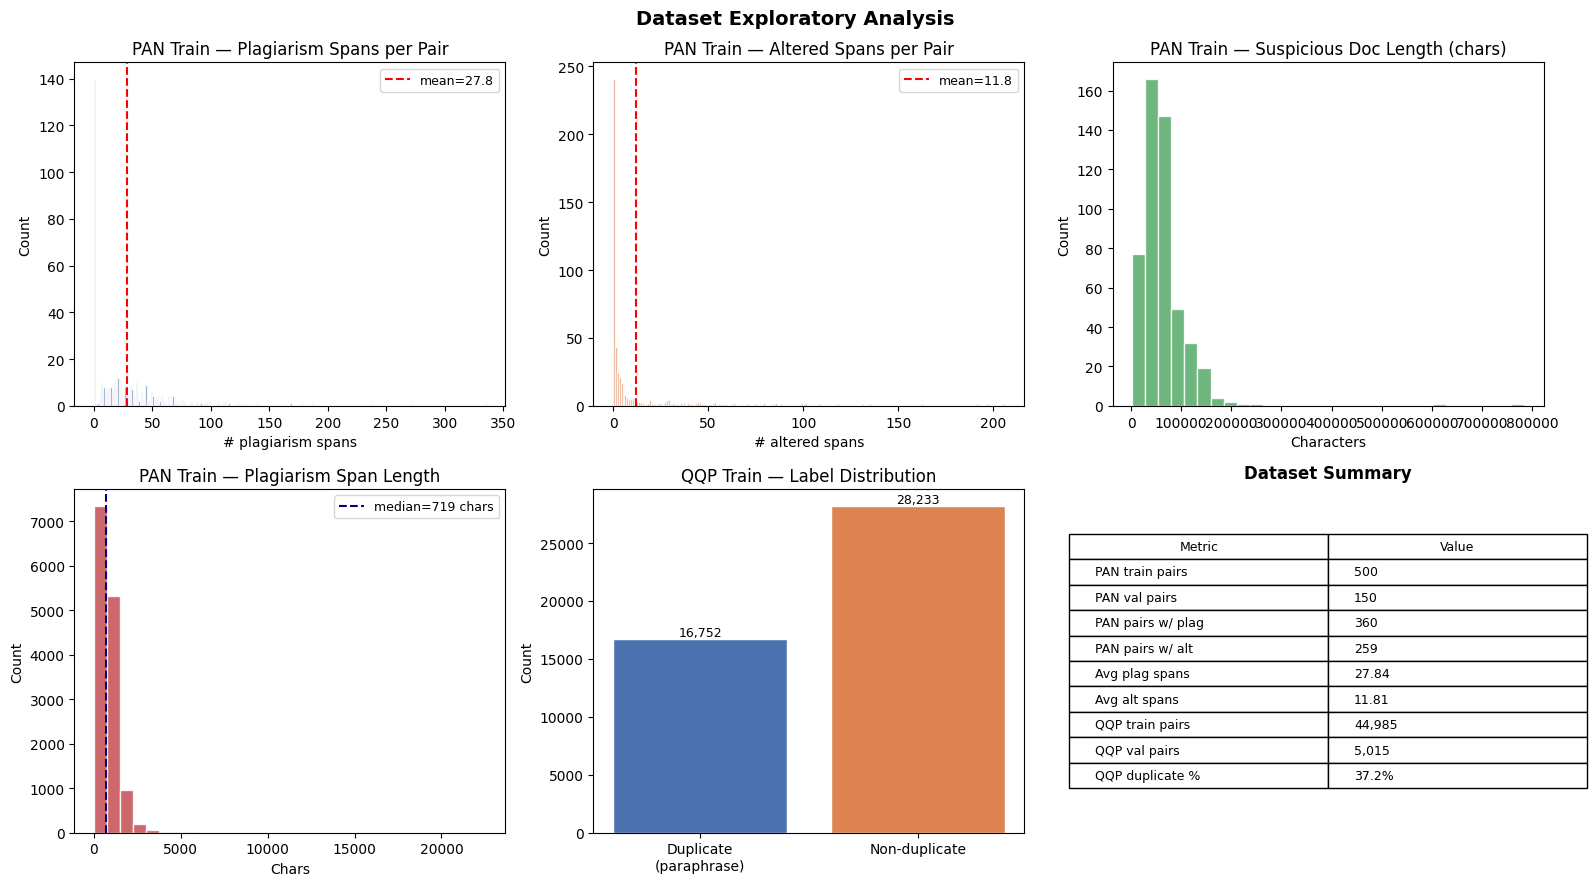


Dataset summary saved.


In [10]:
# Dataset Exploratory Analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Dataset Exploratory Analysis", fontsize=14, fontweight="bold")

# PAN plagiarism spans per pair
ax = axes[0, 0]
n_spans = [r["num_plagiarism_spans"] for r in pan_train]
ax.hist(n_spans, bins=range(0, max(n_spans)+2), color="#4C72B0", edgecolor="white", alpha=0.85)
ax.set_title("PAN Train — Plagiarism Spans per Pair")
ax.set_xlabel("# plagiarism spans"); ax.set_ylabel("Count")
ax.axvline(np.mean(n_spans), color="red", ls="--",
           label=f"mean={np.mean(n_spans):.1f}")
ax.legend(fontsize=9)

#  PAN altered spans per pair
ax = axes[0, 1]
n_alt = [r["num_altered_spans"] for r in pan_train]
ax.hist(n_alt, bins=range(0, max(n_alt)+2), color="#DD8452", edgecolor="white", alpha=0.85)
ax.set_title("PAN Train — Altered Spans per Pair")
ax.set_xlabel("# altered spans"); ax.set_ylabel("Count")
ax.axvline(np.mean(n_alt), color="red", ls="--",
           label=f"mean={np.mean(n_alt):.1f}")
ax.legend(fontsize=9)

#  PAN suspicious document lengths (chars)
ax = axes[0, 2]
susp_lens = [len(r["susp_text"]) for r in pan_train]
ax.hist(susp_lens, bins=30, color="#55A868", edgecolor="white", alpha=0.85)
ax.set_title("PAN Train — Suspicious Doc Length (chars)")
ax.set_xlabel("Characters"); ax.set_ylabel("Count")

# PAN plagiarism span length distribution
ax = axes[1, 0]
span_lens = [s["this_length"]
             for r in pan_train for s in r["plagiarism_spans"]]
if span_lens:
    ax.hist(span_lens, bins=30, color="#C44E52", edgecolor="white", alpha=0.85)
    ax.axvline(np.median(span_lens), color="navy", ls="--",
               label=f"median={np.median(span_lens):.0f} chars")
ax.set_title("PAN Train — Plagiarism Span Length")
ax.set_xlabel("Chars"); ax.set_ylabel("Count")
ax.legend(fontsize=9)

#  QQP label distribution
ax = axes[1, 1]
dup_count  = sum(r["label"] for r in qqp_train)
ndup_count = len(qqp_train) - dup_count
ax.bar(["Duplicate\n(paraphrase)", "Non-duplicate"],
       [dup_count, ndup_count],
       color=["#4C72B0", "#DD8452"], edgecolor="white")
ax.set_title("QQP Train — Label Distribution")
ax.set_ylabel("Count")
for i, v in enumerate([dup_count, ndup_count]):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)


ax = axes[1, 2]
ax.axis("off")
rows = [
    ["PAN train pairs",    f"{len(pan_train):,}"],
    ["PAN val pairs",      f"{len(pan_val):,}"],
    ["PAN pairs w/ plag",  f"{sum(r['num_plagiarism_spans']>0 for r in pan_train):,}"],
    ["PAN pairs w/ alt",   f"{sum(r['num_altered_spans']>0 for r in pan_train):,}"],
    ["Avg plag spans",     f"{np.mean([r['num_plagiarism_spans'] for r in pan_train]):.2f}"],
    ["Avg alt spans",      f"{np.mean([r['num_altered_spans'] for r in pan_train]):.2f}"],
    ["QQP train pairs",    f"{len(qqp_train):,}"],
    ["QQP val pairs",      f"{len(qqp_val):,}"],
    ["QQP duplicate %",    f"{100*dup_count/len(qqp_train):.1f}%"],
]
tbl = ax.table(cellText=rows, colLabels=["Metric", "Value"],
               loc="center", cellLoc="left")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.scale(1.2, 1.4)
ax.set_title("Dataset Summary", fontweight="bold", pad=8)

plt.tight_layout()
savefig("01_dataset_eda")
print("\nDataset summary saved.")


##  Preprocessing & Chunking



In [13]:
#  Text normalisation
import unicodedata

def normalise_text(text: str) -> str:
    """Light normalisation: unicode NFC, collapse whitespace, strip trailing spaces."""
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\r\n?", "\n", text)
    text = "\n".join(line.rstrip() for line in text.splitlines())
    return text.strip()

#  Chunking with character-offset mapping
from transformers import AutoTokenizer

_tokenizer = AutoTokenizer.from_pretrained(CFG["bi_encoder_model"])

def chunk_text_with_offsets(text: str,
                             chunk_size: int = 128,
                             stride: int = 64) -> list:
    """
    Tokenise text and produce overlapping windows.
    Each chunk dict carries:
      text        – decoded chunk text
      char_start  – character start in original text
      char_end    – character end in original text
      tok_start   – token window start index
      tok_end     – token window end index
    """
    enc = _tokenizer(text,
                     return_offsets_mapping=True,
                     truncation=False,
                     add_special_tokens=False)
    ids     = enc["input_ids"]
    offsets = enc["offset_mapping"]

    if not ids:
        return [{"text": text[:512], "char_start": 0,
                 "char_end": len(text), "tok_start": 0, "tok_end": 0}]

    chunks = []
    start  = 0
    while start < len(ids):
        end  = min(start + chunk_size, len(ids))
        c_s  = offsets[start][0]
        c_e  = offsets[end - 1][1]
        chunks.append({
            "text"      : text[c_s:c_e],
            "char_start": c_s,
            "char_end"  : c_e,
            "tok_start" : start,
            "tok_end"   : end,
        })
        if end == len(ids):
            break
        start += stride
    return chunks


def build_chunks_for_pair(record: dict) -> tuple:
    susp_text = normalise_text(record["susp_text"])
    src_text  = normalise_text(record["src_text"])
    susp_chunks = chunk_text_with_offsets(susp_text, CFG["chunk_size"], CFG["chunk_stride"])
    src_chunks  = chunk_text_with_offsets(src_text,  CFG["chunk_size"], CFG["chunk_stride"])
    return susp_chunks, src_chunks


_ex = pan_train[0]
_sc, _rc = build_chunks_for_pair(_ex)
print(f"Example pair: {_ex['pair_id']}")
print(f"  Suspicious: {len(_ex['susp_text']):,} chars  {len(_sc)} chunks")
print(f"  Source    : {len(_ex['src_text']):,} chars  {len(_rc)} chunks")
print(f"  First susp chunk [{_sc[0]['char_start']}-{_sc[0]['char_end']}]: \"{_sc[0]['text'][:80]}...\"")


Token indices sequence length is longer than the specified maximum sequence length for this model (5488 > 512). Running this sequence through the model will result in indexing errors


Example pair: suspicious-document020468__source-document020468
  Suspicious: 22,260 chars  85 chunks
  Source    : 77,555 chars  331 chunks
  First susp chunk [0-742]: "Quest for HI Turbulence Statistics: New Techniques

By A. Lazarian and D. Pogosy..."


In [14]:
# Build chunk datasets for train and val
def build_chunk_dataset(records, desc="chunks"):

    result = []
    for r in tqdm(records, desc=desc):
        susp_chunks, src_chunks = build_chunks_for_pair(r)
        result.append({
            "pair_id"          : r["pair_id"],
            "susp_chunks"      : susp_chunks,
            "src_chunks"       : src_chunks,
            "plagiarism_spans" : r["plagiarism_spans"],
            "altered_spans"    : r["altered_spans"],
        })
    return result

with Timer("chunking"):
    if has_ckpt("chunk_train") and has_ckpt("chunk_val"):
        chunk_train = load_ckpt("chunk_train")
        chunk_val   = load_ckpt("chunk_val")
    else:
        chunk_train = build_chunk_dataset(pan_train, "chunk train")
        chunk_val   = build_chunk_dataset(pan_val,   "chunk val")
        save_ckpt("chunk_train", chunk_train)
        save_ckpt("chunk_val",   chunk_val)

total_susp = sum(len(r["susp_chunks"]) for r in chunk_train)
total_src  = sum(len(r["src_chunks"])  for r in chunk_train)
print(f"\nTrain — suspicious chunks: {total_susp:,}")
print(f"Train — source chunks     : {total_src:,}")
print(f"Val   — suspicious chunks : {sum(len(r['susp_chunks']) for r in chunk_val):,}")

def chunk_overlaps_span(chunk_start, chunk_end, span_start, span_end):
    return chunk_start < span_end and chunk_end > span_start

def get_positive_chunk_pairs(pair_record):
    """Return (susp_chunk_idx, src_chunk_idx) pairs that overlap a plagiarism span."""
    positives = []
    for si, sc in enumerate(pair_record["susp_chunks"]):
        for plag in pair_record["plagiarism_spans"]:
            if chunk_overlaps_span(sc["char_start"], sc["char_end"],
                                   plag["this_offset"], plag["this_end"]):
                for ri, rc in enumerate(pair_record["src_chunks"]):
                    if chunk_overlaps_span(rc["char_start"], rc["char_end"],
                                           plag["source_offset"], plag["source_end"]):
                        positives.append((si, ri))
    return list(set(positives))

print("\nChunk-level positive pair counts:")
pos_counts = [len(get_positive_chunk_pairs(r)) for r in chunk_train]
print(f"  Mean: {np.mean(pos_counts):.1f}  Max: {max(pos_counts)}  "
      f"Total: {sum(pos_counts):,}")



  [chunking] started …


chunk train:   0%|          | 0/500 [00:00<?, ?it/s]

chunk val:   0%|          | 0/150 [00:00<?, ?it/s]

   Checkpoint saved  [chunk_train]  (150.1 MB)
   Checkpoint saved  [chunk_val]  (45.5 MB)
  [chunking] done in 2.0 min

Train — suspicious chunks: 171,917
Train — source chunks     : 200,867
Val   — suspicious chunks : 53,681

Chunk-level positive pair counts:
  Mean: 1547.6  Max: 37435  Total: 773,798
